# CNV benchmark

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [226]:
base_path = Path("../analysis/cnv_benchmark")

samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Single cell


## Agreement

In [230]:
data = []

for tsv in (base_path / "agreement").rglob("*.tsv"):
    binsize, benchtype = tsv.stem.split(".")
    truthset = tsv.parent.stem
    readdepth = tsv.parent.parent.stem
    caller = tsv.parent.parent.parent.stem

    df = pd.read_csv(tsv, sep="\t", names=["NGI ID", "Agreement"])
    df["Truthset"] = truthset
    df["Caller"] = caller
    df["Binsize"] = binsize
    df["Readdepth"] = readdepth
    df["Benchtype"] = benchtype
    data.append(df)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="NGI ID")
data = data.query("Genome == 'Human'")
data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
data

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/1696498196.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/1696498196.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)


,NGI ID,Agreement,Truthset,Caller,Binsize,Readdepth,Benchtype,User ID,IsSingleCell,Kit,Sample,Genome,Type,Caller_Binsize,Kit_Readdepth
0,P33410_1001,0.839569,PacBio_HiFi,copykit,220kb,full,gl,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,copykit\n(220kb),Qiagen (full)
1,P33410_1002,0.709012,PacBio_HiFi,copykit,220kb,full,gl,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell,copykit\n(220kb),Qiagen (full)
2,P33410_1003,0.595995,PacBio_HiFi,copykit,220kb,full,gl,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell,copykit\n(220kb),Qiagen (full)
3,P33410_1004,0.894566,PacBio_HiFi,copykit,220kb,full,gl,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Single cell,copykit\n(220kb),Qiagen (full)
4,P33410_1005,0.833875,PacBio_HiFi,copykit,220kb,full,gl,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Single cell,copykit\n(220kb),Qiagen (full)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,P33410_1019,0.493479,OGM,ginkgo,1Mb,2M,gl,B_C1_cell_07,True,BioSkryb,MM1S cell line,Human,Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1060,P33410_1020,0.548465,OGM,ginkgo,1Mb,2M,gl,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1061,P33410_1021,0.864922,OGM,ginkgo,1Mb,2M,gl,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,Single cell,ginkgo\n(1Mb),BioSkryb (2M)
1062,P33410_1022,0.857328,OGM,ginkgo,1Mb,2M,gl,B_C4_cell_10,True,BioSkryb,MM1S cell line,Human,Single cell,ginkgo\n(1Mb),BioSkryb (2M)


In [245]:
def plot_agreement(d, ylabel, filename=None):
    hue_order = sorted(d["Kit_Readdepth"].unique())
    order = [
        'copykit\n(110kb)',
        'copykit\n(220kb)',
        'copykit\n(500kb)',
        'copykit\n(1Mb)',
        'ginkgo\n(1Mb)'
    ]
    palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
    g = sns.catplot(
        data=d, 
        kind="swarm",
        x="Caller_Binsize",
        order=order, 
        y="Agreement", 
        hue="Kit_Readdepth",
        hue_order=hue_order,
        palette=palette,
        row="Truthset",
        aspect=3, 
        s=15,
        height=2.5,
        dodge=True,
        width=0.3,
    )

    g.map_dataframe(
        sns.violinplot,
        data=d, 
        x="Caller_Binsize",
        y="Agreement",
        inner="quart", 
        fill=None, 
        hue="Kit_Readdepth",
        hue_order=hue_order,
        palette="dark:k", 
        dodge=True,
        density_norm="width",
        zorder=-1,
        alpha=0.9,
        cut=0.5,
    )

    g.set(ylabel=ylabel, xlabel="")

    for ax in g.axes.flat:
        ax.set_ylim(bottom=0)
        ax.grid(True, axis='y', alpha=0.5)
    
    if filename:
        plt.savefig(filename, bbox_inches="tight")

### Copy number agreement

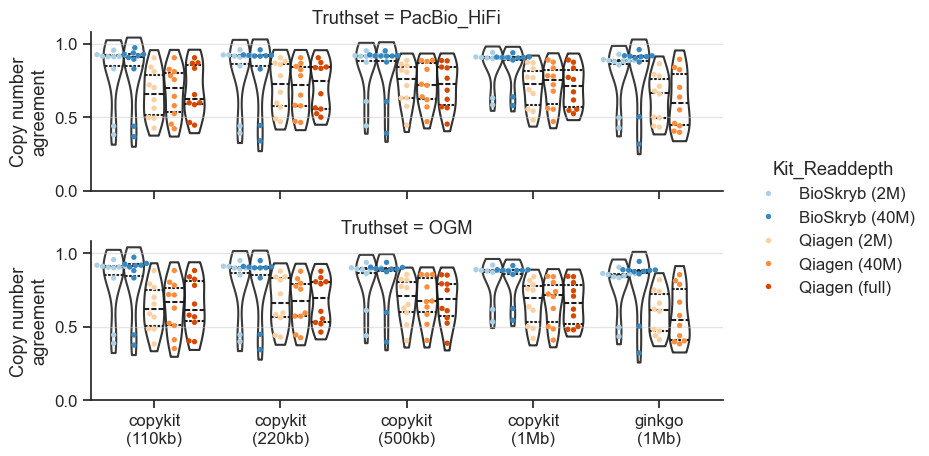

In [246]:
d = data.query("IsSingleCell == True & Benchtype == 'cn'")
plot_agreement(d, "Copy number\nagreement", figdir / "cnv_benchmark_singlecell_cn_agreement.svg")

### Gain/loss agreement

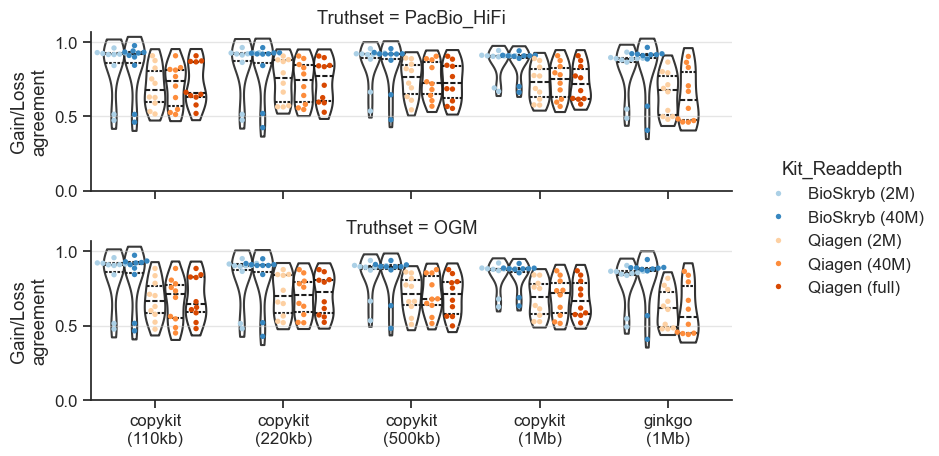

In [247]:
d = data.query("IsSingleCell == True & Benchtype == 'gl'")
plot_agreement(d, "Gain/Loss\nagreement", figdir / "cnv_benchmark_singlecell_gl_agreement.svg")

### Copy number agreement (w/o B cell 7&8)

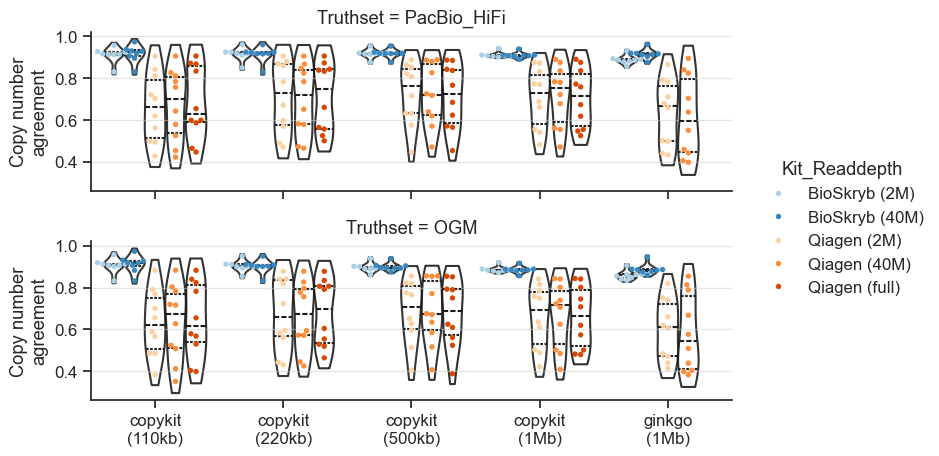

In [240]:
d = data.query("IsSingleCell == True & Benchtype == 'cn'")
skip_samples = [
    'B_C1_cell_07',
    'B_C2_cell_08',
]
d = d[~(d["User ID"].isin(skip_samples))]

plot_agreement(d, "Copy number\nagreement", figdir / "cnv_benchmark_singlecell_cn_agreement_filtered.svg")

### Gain/loss agreement (w/o B cell 7&8)

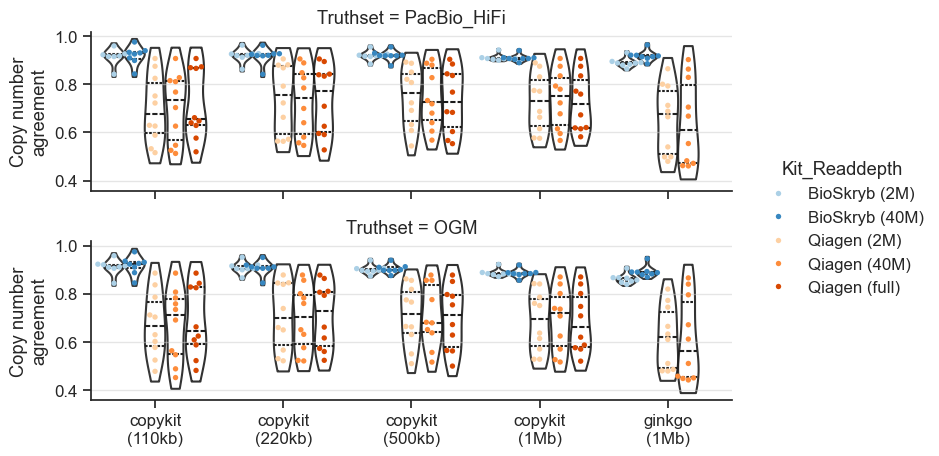

In [241]:
d = data.query("IsSingleCell == True & Benchtype == 'gl'")
skip_samples = [
    'B_C1_cell_07',
    'B_C2_cell_08',
]
d = d[~(d["User ID"].isin(skip_samples))]
plot_agreement(d, "Copy number\nagreement", figdir / "cnv_benchmark_singlecell_gl_agreement_filtered.svg")

### Bulk samples

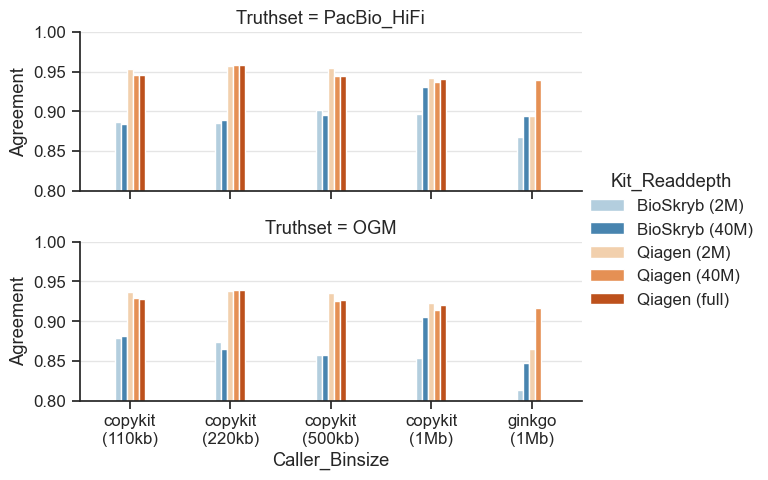

In [194]:
d = data.query("IsSingleCell == False & Benchtype == 'cn'")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.catplot(
    data=d, 
    kind="bar",
    x="Caller_Binsize",
    order=order, 
    y="Agreement", 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    row="Truthset",
    aspect=2.5, 
    height=2.5,
    dodge=True,
    width=0.3,
)
g.set(ylim=(0.8, 1))
# Add grid
for ax in g.axes.flat:
    ax.grid(True, axis='y', alpha=0.5)

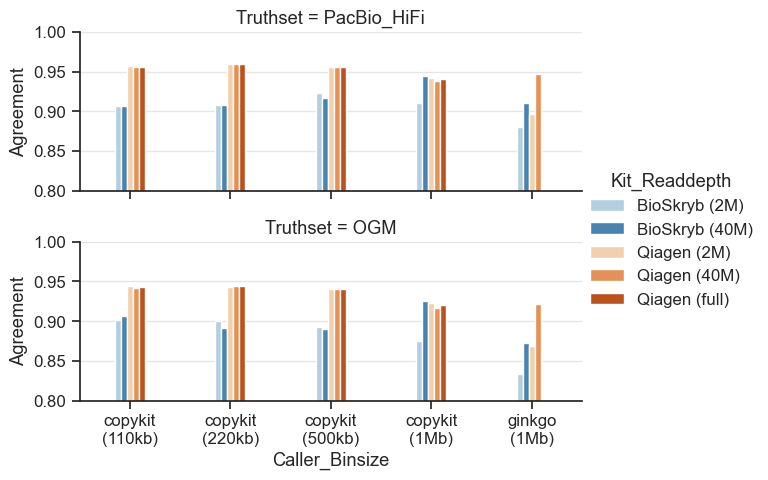

In [195]:
d = data.query("IsSingleCell == False & Benchtype == 'gl'")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.catplot(
    data=d, 
    kind="bar",
    x="Caller_Binsize",
    order=order, 
    y="Agreement", 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    row="Truthset",
    aspect=2.5, 
    height=2.5,
    dodge=True,
    width=0.3,
)
g.set(ylim=(0.8, 1))
# Add grid
for ax in g.axes.flat:
    ax.grid(True, axis='y', alpha=0.5)

### Read depth improvement

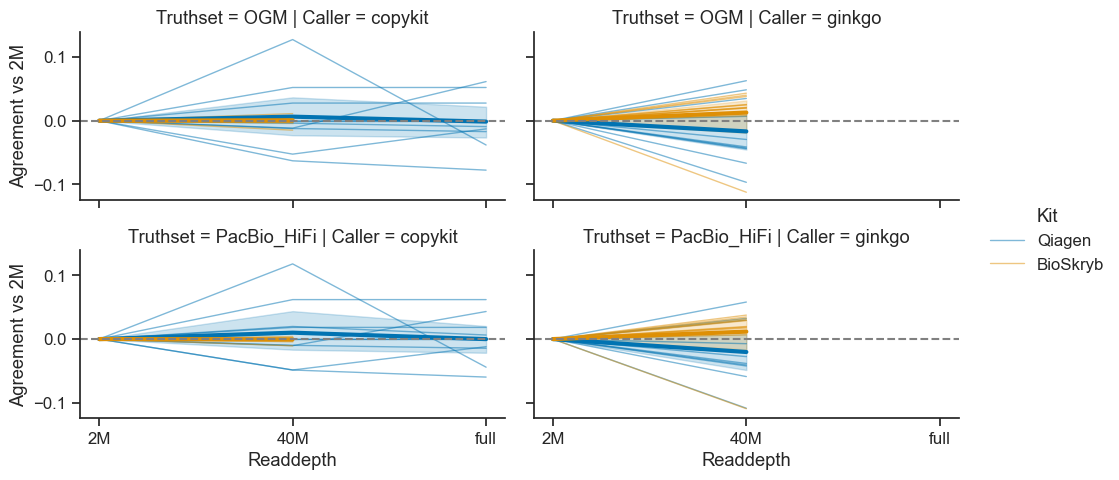

In [204]:
d = data.query("Benchtype == 'cn' & Binsize == '1Mb' & IsSingleCell == True")
d = d.sort_values("Readdepth")
d["Agreement vs 2M"] = d.groupby(["NGI ID", "Caller", "Truthset"])["Agreement"].transform(lambda x: x - x.iloc[0])
g = sns.relplot(
    data=d, 
    kind="line",
    x="Readdepth",
    #size="Binsize",
    #size_order=reversed(["110kb", "220kb", "500kb", "1Mb"]),
    #order=order, 
    col="Caller",
    #style_order=[True, False],
    hue_order=["Qiagen", "BioSkryb"],
    y="Agreement vs 2M",
    hue="Kit",
    row="Truthset",
    aspect=2, 
    height=2.5,
    lw=1,
    estimator=None,
    alpha=0.5,
    units="NGI ID",
    #dodge=True,
    #width=0.3,
)
g.map_dataframe(
    sns.lineplot,
    x="Readdepth",
    y="Agreement vs 2M",
    hue="Kit",
    data=d, 
    hue_order=["Qiagen", "BioSkryb"],
    lw=3,
)
g.refline(y=0)
#g.set(ylim=(0, 1))

## Agreement truthsets

In [249]:
truth = []
t1 = pd.read_csv(base_path / "agreement_truthsets.cn.tsv", sep="\t", names=["Query", "Agreement"])
t1["Benchtype"] = "Copy number"
t2 = pd.read_csv(base_path / "agreement_truthsets.gl.tsv", sep="\t", names=["Query", "Agreement"])
t2["Benchtype"] = "Gain/Loss"
truth = pd.concat([t1, t2])
truth


,Query,Agreement,Benchtype
0,OGM,0.987892,Copy number
0,OGM,0.990732,Gain/Loss


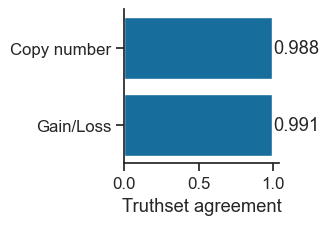

In [255]:
fig, ax = plt.subplots(figsize=(2, 2))
ax = sns.barplot(data=truth, y="Benchtype", x="Agreement")
ax.set_xlabel("Truthset agreement")
ax.set_ylabel("")

# Add values after bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", (p.get_width() * 1.01, p.get_y() + p.get_height() / 2), ha="left", va="center")

## Truthsets comparison

In [408]:
def parse_fai(fai):
    with open(fai) as f:
        for line in f:
            chrom, length, *_ = line.strip().split("\t")
            yield chrom, int(length)


def parse_seg(seg):
    with open(seg) as f:
        for line in f:
            if line.startswith("#"):
                continue
            
            # The third column should be an integer
            if not line.strip().split("\t")[2].isdigit():
                continue

            els = line.strip().split("\t")
            name = els[0]
            chrom = els[1]
            start = int(els[2])
            end = int(els[3])
            cn = int(els[-1])

            yield name, chrom, start, end, cn

ogm_seg = "../resources/OGM_CNVs/cnv_calls.chr.seg"
pb_seg = "../resources/PacBioHiFi_pr_023_003_MM1S_hificnv/MM1S_excluded.pr_023_003.seg"
fai = "../resources/GRCh38.genome"

chr_lengths = {chrom: length for chrom, length in parse_fai(fai)}

ogm_cnvs = list(parse_seg(ogm_seg))
pb_cnvs = list(parse_seg(pb_seg))

cnvs = pd.DataFrame(ogm_cnvs + pb_cnvs, columns=["Name", "Chrom", "Start", "End", "CN"])
cnvs = cnvs[cnvs["Chrom"].isin(chr1toX)]
#cnvs = cnvs.query("CN != 2")
chromsome_offsets = {}
position = 0
spacing = 20_000_000
for chrom in chr1toX:
    chromsome_offsets[chrom] = position
    position += chr_lengths[chrom] + spacing

cnvs["Position"] = cnvs.apply(lambda x: chromsome_offsets[x["Chrom"]] + x["Start"], axis=1)

cnvs

,Name,Chrom,Start,End,CN,Position
0,OGM,chr1,82856335,85109746,1,82856335
1,OGM,chr1,92697635,100769576,1,92697635
2,OGM,chr1,100783411,107392774,1,100783411
3,OGM,chr1,107403070,120615069,1,107403070
4,OGM,chr1,120924651,121608073,1,120924651
...,...,...,...,...,...,...
261,PacBio_HiFi_HiFiCNV,chrX,62518000,141000000,2,3377519522
262,PacBio_HiFi_HiFiCNV,chrX,141000000,141014000,5,3456001522
263,PacBio_HiFi_HiFiCNV,chrX,141014000,141534000,2,3456015522
264,PacBio_HiFi_HiFiCNV,chrX,141534000,141562000,0,3456535522


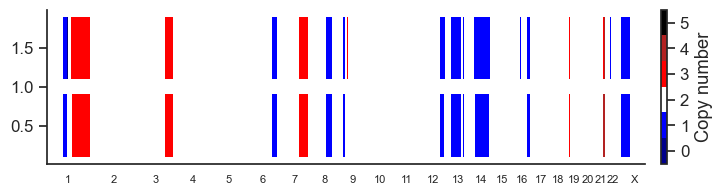

In [416]:
import matplotlib as mpl

cn_colors = {
    0: "darkblue",
    1: "blue",
    2: "white",
    3: "red",
    4: "firebrick",
    5: "darkred",
    6: "black",
}

cmap = mpl.colors.ListedColormap(list(cn_colors.values()))
bounds = list(cn_colors.keys())
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

fig, (ax, cax) = plt.subplots(figsize=(8, 2), ncols=2, 
                       gridspec_kw={"width_ratios": [1,0.01]})

for i, (group, cnv) in enumerate(cnvs.groupby("Name")):
    x = cnv["Position"].values
    bar_widths= (cnv["End"] - cnv["Start"]).values
    y = i + 0.1
    facecolors = norm(cnv["CN"].values)
    facecolors = [cmap(f) for f in facecolors]
    xranges = np.array([x, bar_widths]).T
    ax.broken_barh(
        xranges=xranges,
        yrange=(y, 0.8),
        facecolors=facecolors,
        cmap=cmap,
        linewidth=0,
    )

#  Add a colorbar
cb = mpl.colorbar.ColorbarBase(
    cax,
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    cmap=cmap,
    spacing='proportional', 
    orientation='vertical', label="Copy number"
)
cb.ax.set_yticklabels(["0", "1", "2", "3", "4", "5"])
# Remove minor ticks on colorbar
cb.ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlim(0, cnvs["Position"].max())
ax.xaxis.set_visible(False)
fig.subplots_adjust(wspace=0.05)

# Add chromosome labels and regions to the plot
for i, chrom in enumerate(chr1toX):
    length = chr_lengths[chrom]
    ax.text(chromsome_offsets[chrom] + length / 2, -0.2, chrom.replace("chr", ""), ha="center", va="center", fontsize=8)

    # if i % 2 == 1:
    #     ax.axvspan(chromsome_offsets[chrom], chromsome_offsets[chrom] + length, color="lightgrey", alpha=0.4, zorder=-1)
    # # else:
    #     ax.axvspan(chromsome_offsets[chrom], chromsome_offsets[chrom] + length, color="lightgrey", alpha=0.8, zorder=-1)

    

[('PacBio_HiFi_HiFiCNV', 'chr1', 0, 12930000, 2),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 12930000, 13146000, 0),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 13146000, 50566000, 2),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 50566000, 50984000, 1),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 50984000, 82886000, 2),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 82886000, 85134000, 1),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 85134000, 92702000, 2),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 92702000, 120590000, 1),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 120590000, 120640000, 0),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 120640000, 120678000, 1),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 120678000, 120920000, 0),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 120920000, 121608000, 1),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 124962000, 125170000, 2),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 143474000, 144636000, 3),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 144636000, 144664000, 1),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 144664000, 149484000, 3),
 ('PacBio_HiFi_HiFiCNV', 'chr1', 149484000, 149540000, 5),
 ('PacBio_HiFi_HiFi

## Truvari data

In [151]:
df = pd.read_csv("../analysis/cnv_benchmark/truvari.tsv", sep="\t")
df["NGI ID"] = df["sample"]
df = df.merge(samples, on="NGI ID")
df["Caller_Binsize"] = df[["caller","binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
df["Kit_Readdepth"] = df[["Kit","reads"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
df

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/4066613567.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["Caller_Binsize"] = df[["caller","binsize"]].apply(lambda x: f"{x[0]}\n({x[1]})", axis=1)
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/4066613567.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["Kit_Readdepth"] = df[["Kit","reads"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)


,caller,reads,binsize,sample,TP-base,TP-comp,FP,FN,precision,recall,...,gt_concordance,gt_matrix,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Caller_Binsize,Kit_Readdepth
0,copykit,2M,110kb,P33410_1001,7,7,14,72,0.333333,0.088608,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
1,copykit,2M,110kb,P33410_1002,6,6,26,73,0.187500,0.075949,...,1.0,"{'(0, 1)': {'(0, 1)': 6}}",P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
2,copykit,2M,110kb,P33410_1003,7,7,26,72,0.212121,0.088608,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
3,copykit,2M,110kb,P33410_1004,7,7,13,72,0.350000,0.088608,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
4,copykit,2M,110kb,P33410_1005,5,5,24,74,0.172414,0.063291,...,1.0,"{'(0, 1)': {'(0, 1)': 5}}",P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,copykit\n(110kb),Qiagen (2M)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,ginkgo,40M,1Mb,P33410_1019,7,7,82,25,0.078652,0.218750,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1019,B_C1_cell_07,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)
216,ginkgo,40M,1Mb,P33410_1020,5,5,48,27,0.094340,0.156250,...,1.0,"{'(0, 1)': {'(0, 1)': 5}}",P33410_1020,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)
217,ginkgo,40M,1Mb,P33410_1021,7,7,11,25,0.388889,0.218750,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1021,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)
218,ginkgo,40M,1Mb,P33410_1022,7,7,12,25,0.368421,0.218750,...,1.0,"{'(0, 1)': {'(0, 1)': 7}}",P33410_1022,B_C4_cell_10,True,BioSkryb,MM1S cell line,Human,ginkgo\n(1Mb),BioSkryb (40M)


/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2147112444.py:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.swarmplot(
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2147112444.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax = sns.violinplot(


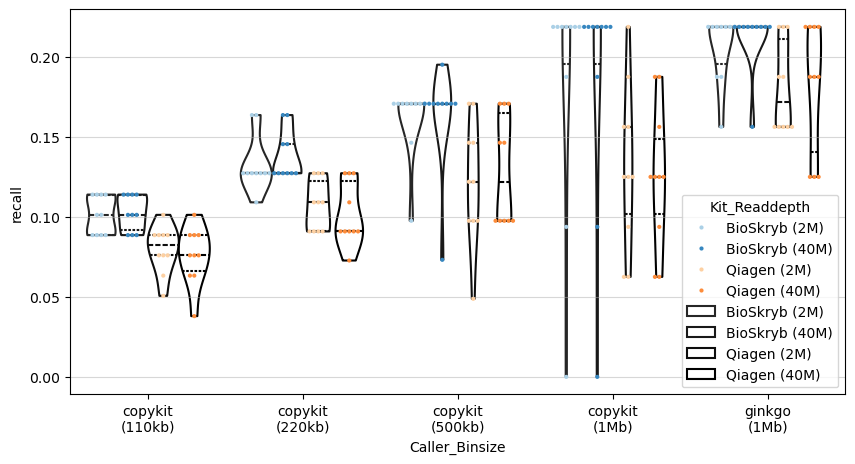

In [155]:
d = df.query("IsSingleCell == True")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "recall"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.swarmplot(
    data=d, 
    x="Caller_Binsize",
    order=order, 
    y=score, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=3,
    dodge=True,
    ax=ax
)
ax = sns.violinplot(
    data=d, 
    x="Caller_Binsize",
    y=score,
    inner="quart", 
    fill=None, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    color="k", 
    dodge=True,
    zorder=-1,
    cut=0,
)
ax.grid(True, axis='y', alpha=0.5)

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2964249.py:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.swarmplot(
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2964249.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax = sns.violinplot(


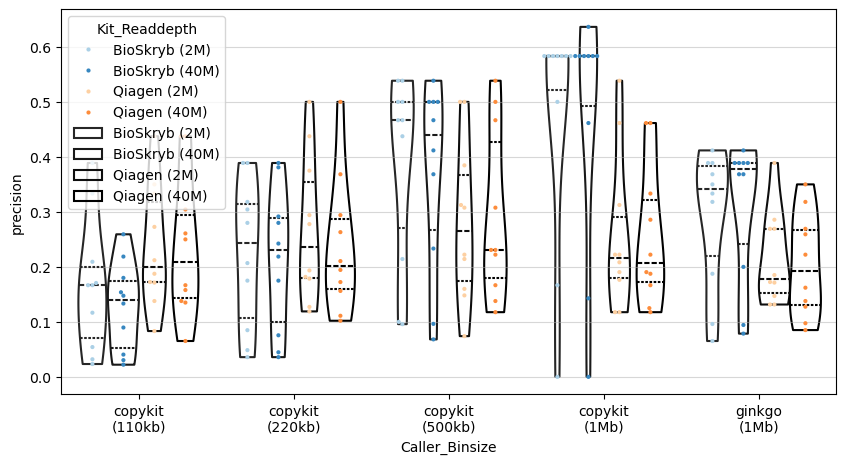

In [156]:
d = df.query("IsSingleCell == True")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "precision"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.swarmplot(
    data=d, 
    x="Caller_Binsize",
    order=order, 
    y=score, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=3,
    dodge=True,
    ax=ax
)
ax = sns.violinplot(
    data=d, 
    x="Caller_Binsize",
    y=score,
    inner="quart", 
    fill=None, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    color="k", 
    dodge=True,
    zorder=-1,
    cut=0,
)
ax.grid(True, axis='y', alpha=0.5)

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/776355916.py:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.swarmplot(
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/776355916.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax = sns.violinplot(


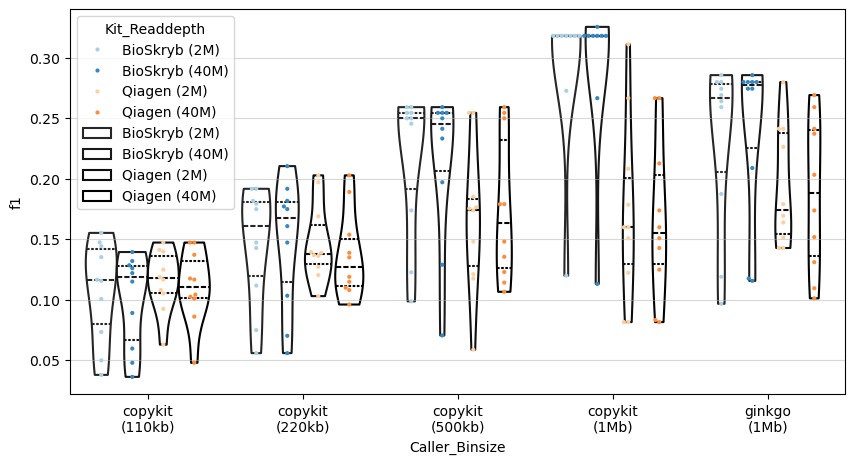

In [157]:
d = df.query("IsSingleCell == True")

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "f1"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.swarmplot(
    data=d, 
    x="Caller_Binsize",
    order=order, 
    y=score, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=3,
    dodge=True,
    ax=ax
)
ax = sns.violinplot(
    data=d, 
    x="Caller_Binsize",
    y=score,
    inner="quart", 
    fill=None, 
    hue="Kit_Readdepth",
    hue_order=hue_order,
    color="k", 
    dodge=True,
    zorder=-1,
    cut=0,
)
ax.grid(True, axis='y', alpha=0.5)

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_51888/2728239462.py:19: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  g = sns.relplot(


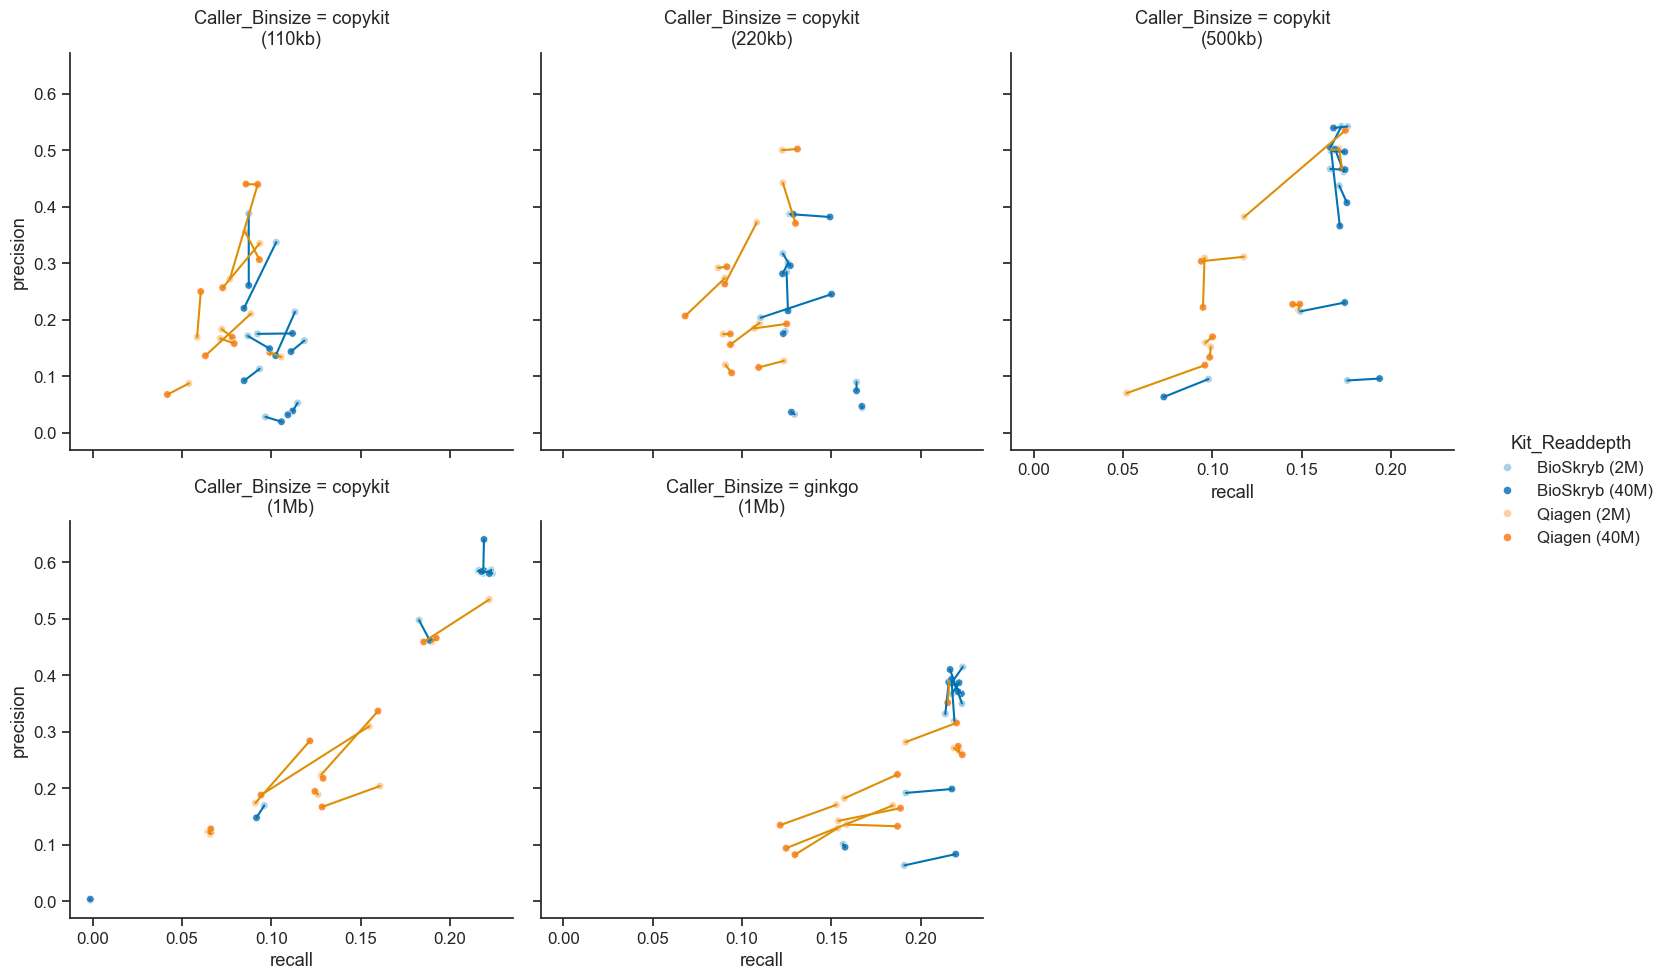

In [223]:
import random
def jitter(x, jitter):
    return x + random.uniform(-jitter, jitter)

d = df.query("IsSingleCell == True").copy()
d["recall"] = d["recall"].apply(lambda x: jitter(x, 0.005))
d["precision"] = d["precision"].apply(lambda x: jitter(x, 0.005))

hue_order = sorted(d["Kit_Readdepth"].unique())
order = [
    'copykit\n(110kb)',
    'copykit\n(220kb)',
    'copykit\n(500kb)',
    'copykit\n(1Mb)',
    'ginkgo\n(1Mb)'
]
score = "f1"
palette = sns.color_palette("Blues", n_colors=2) + sns.color_palette("Oranges", n_colors=3)
g = sns.relplot(
    kind="scatter",
    data=d, 
    x="recall",
    y="precision",
    col="Caller_Binsize",
    col_wrap=3,
    hue="Kit_Readdepth",
    hue_order=hue_order,
    palette=palette,
    s=30,
)
g.map_dataframe(
    sns.lineplot,
    data=d,
    x="recall",
    y="precision",
    hue="Kit",
    hue_order=["BioSkryb", "Qiagen"],
    units="NGI ID",
    estimator=None,
)
